In [1]:
import torch
from torch.distributions import Dirichlet, Categorical, Normal
import matplotlib.pyplot as plt
import matplotlib as mpl
import mpltern
import numpy as np
import pandas as pd

# Synthic Controllable CF Construction

## Create Dirichlet distribution and capture AU, EU and TU

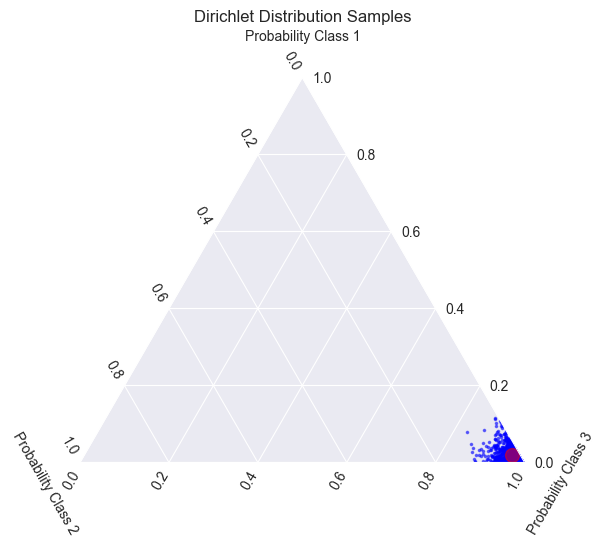

In [2]:
alphas = np.array([1.0, 1.0, 50.0])


dirichlet_distribution = Dirichlet(torch.tensor(alphas))
# Generate 1000 samples
samples = dirichlet_distribution.sample((1000,))
# Convert to a numpy array
samples = samples.numpy()
# Plot the samples in Baracentric coordinates
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5), subplot_kw={'projection': 'ternary','ternary_sum':1})
ax.scatter(samples[:,0], samples[:,1], samples[:,2], marker='.', s=10, alpha=0.5, color='blue')
ax.scatter(alphas[0], alphas[1], alphas[2], marker='o', s=100, alpha=0.5, color='red')
ax.set_title("Dirichlet Distribution Samples")
ax.set_tlabel("Probability Class 1")
ax.set_llabel("Probability Class 2")
ax.set_rlabel("Probability Class 3")
plt.show()


In [3]:
def calculate_au_eu_tu(dirchilet_distribution):
    """
    Calculate the AU, EU, and TU for a given Dirichlet distribution.
    """
    alph = dirchilet_distribution.concentration
    a0 = alph.sum(-1,keepdim=True)
    classes = alph.size(-1)
    mean_probability = dirchilet_distribution.mean
    # TU
    tu = Categorical(mean_probability).entropy() / torch.log(torch.tensor(classes))
    # AU
    au = -(torch.digamma(alph   +  1) - torch.digamma(a0 + 1)).mul(mean_probability).sum(-1) / torch.log(torch.tensor(classes))
    # EU
    eu = classes / a0.squeeze()
    return au, eu, tu

def calculate_au_eu_tu_sampled(dirchilet_distribution, n_samples=1000):
    """
    Calculate the AU, EU, and TU for a given Dirichlet distribution using sampled points.
    """
    # Sample points from the Dirichlet distribution
    samples = dirchilet_distribution.sample((n_samples,))
    normalizer = torch.log(torch.tensor(samples.size(-1)))
    # TU
    tu = Categorical(samples.mean(dim=0)).entropy().div(normalizer)
    # AU
    au = Categorical(samples).entropy().div(normalizer).mean(dim=0)
    # EU
    eu = (tu - au).clip(0,1)

    return au, eu, tu

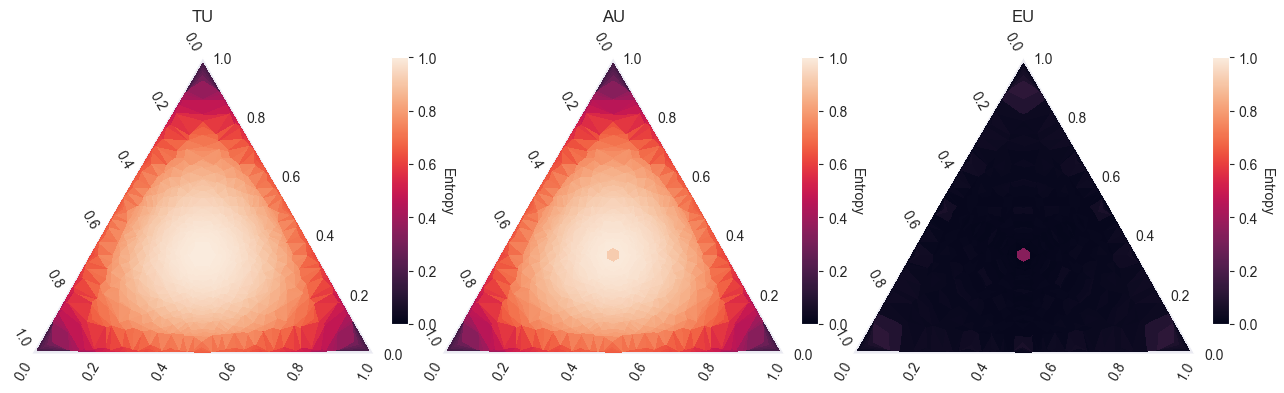

In [4]:

# Build Contour plot of AU, EU, and TU for different alphas
def build_contour_plot():
    """
    Build a contour plot of AU, EU, and TU for different alphas.
    """
    # Create a grid of alphas
    alpha0 = np.linspace(1, 100, 10)
    alpha1 = np.linspace(1, 100, 10)
    alpha2 = np.linspace(1, 100, 10)
    alpha0, alpha1, alpha2 = np.meshgrid(alpha0, alpha1, alpha2)
    # Calculate AU, EU, and TU
    points = np.array([alpha0.flatten(), alpha1.flatten(), alpha2.flatten()]).T
    dist = Dirichlet(torch.tensor(points))
    au,eu,tu = calculate_au_eu_tu(dist)

    # Plot the contour plot
    fig, axes = plt.subplots(nrows=1, ncols=3,figsize=(15,5), subplot_kw={'projection': 'ternary','ternary_sum':1})
    vmin=0
    vmax = 1

    # Plot AU
    ax = axes[0]
    cs = ax.tripcolor(points[:,0],points[:,1],points[:,2], tu, shading='flat', vmin=vmin, vmax=vmax)
    ax.set_title("TU")
    cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
    colorbar = fig.colorbar(cs, cax=cax)
    colorbar.set_label('Entropy', rotation=270, va='baseline')

    # Plot TU
    ax = axes[1]
    cs = ax.tripcolor(points[:,0],points[:,1],points[:,2], au, shading='flat', vmin=vmin, vmax=vmax)
    ax.set_title("AU")
    cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
    colorbar = fig.colorbar(cs, cax=cax)
    colorbar.set_label('Entropy', rotation=270, va='baseline')

    # Plot EU
    ax = axes[2]
    cs = ax.tripcolor(points[:,0],points[:,1],points[:,2], eu, shading='flat', vmin=vmin, vmax=vmax)
    ax.set_title("EU")
    cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
    colorbar = fig.colorbar(cs, cax=cax)
    colorbar.set_label('Entropy', rotation=270, va='baseline')

    plt.show()

build_contour_plot()

## Create synthetic classification dataset

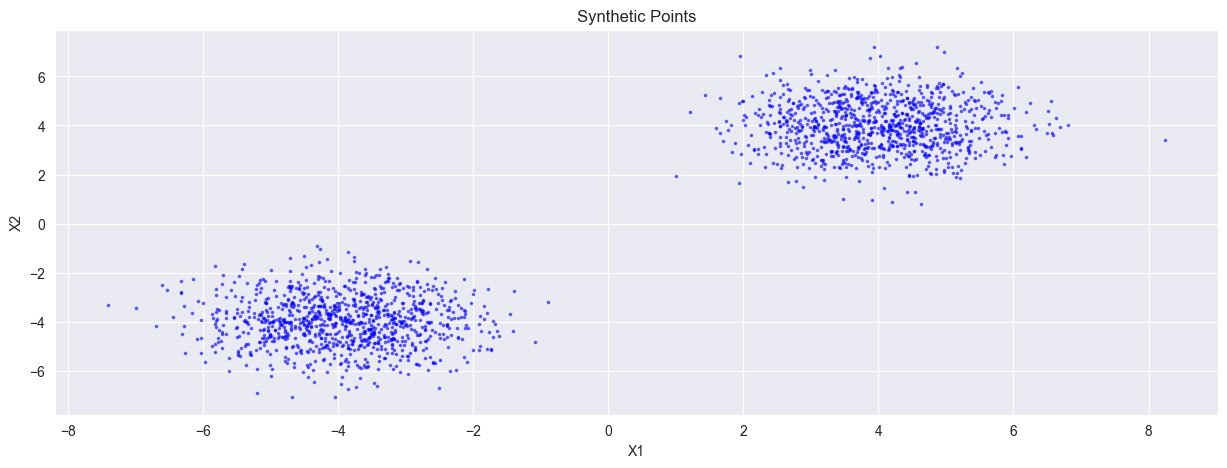

In [5]:
def generate_x_points(n_samples=1000,bias=1):
    """
    Generate n_samples points in the simplex.
    """
    # Generate random points in the simplex
    x1_corr = Normal(0, 1).sample((n_samples,))
    x2_corr = Normal(0, 1).sample((n_samples,))
    points = torch.stack([x1_corr, x2_corr], dim=1).numpy() + bias
    return points

# visualize the points
def visualize_points(points):
    """
    Visualize the points in the simplex.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    ax.scatter(points[:,0], points[:,1], marker='.', s=10, alpha=0.5, color='blue')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.show()

# Generate points
point_bunch = generate_x_points(bias=-4)
point_buncH2 = generate_x_points(bias=4)
points = np.concatenate((point_bunch,point_buncH2),axis=0)
# Visualize points
visualize_points(points)

In [6]:
# define 2nd order data generating process

def generate_2nd_order_beliefs(points):
    if type(points) == np.ndarray:
        points = torch.tensor(points, dtype=torch.float32)

    norms = torch.linalg.norm(points, dim=1)
    belief_y_0 = (points.sum(dim=1) < 0)*(norms - norms*(norms > 9))
    belief_y_1 = (points.sum(dim=1) > 0)*(norms - norms*(norms > 9))
    belief_y = torch.stack([belief_y_0, belief_y_1], dim=1).requires_grad_(True)
    alpha_y = belief_y + 1

    return alpha_y

def generate_y_probs(points):
    alpha_y = generate_2nd_order_beliefs(points)
    # Generate y probabilities
    y_probs = Dirichlet(alpha_y).mean
    return y_probs

def generate_target_and_probs(points):
    y_probs = generate_y_probs(points)
    y_labels = torch.argmax(y_probs, dim=1)
    return y_labels, y_probs

y_labels, y_probs = generate_target_and_probs(points)


In [7]:
point = np.array([10,10]).reshape(-1,2)
norm = np.linalg.norm(point, axis=1)
print(norm, norm - norm*(norm > 9))
generate_2nd_order_beliefs(point)

[14.14213562] [0.]


tensor([[1., 1.]], grad_fn=<AddBackward0>)

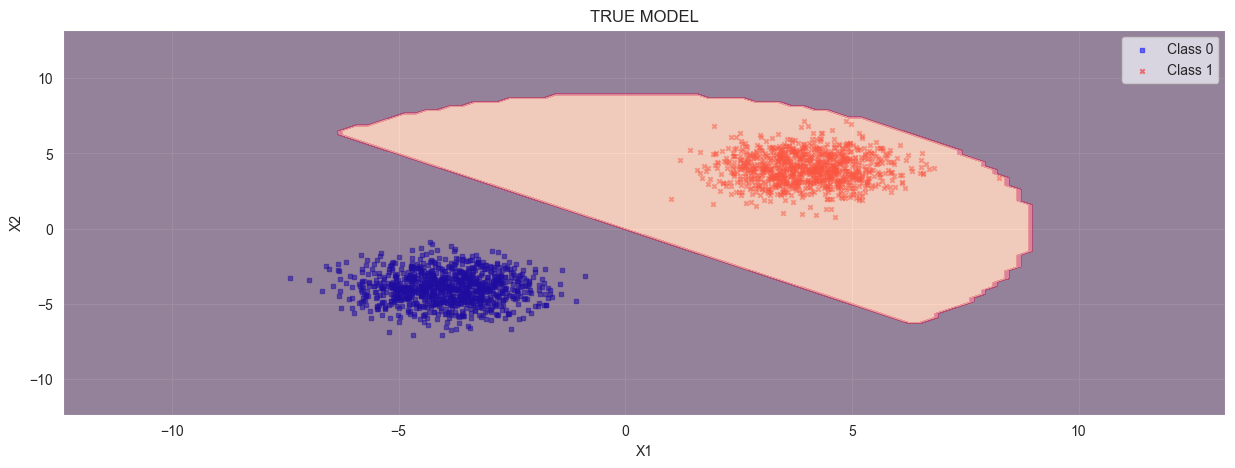

In [8]:
# visualize the labels distribution for the points
def visualize_labels_distribution(points,y_labels):
     # Create gird of points
    grid_points = np.linspace(points.min()-5, points.max()+5, 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    grid_y_labels,_ = generate_target_and_probs(grid_points)

    # Plot the points
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # Plot TU
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.contourf(xx, yy, grid_y_labels.reshape(xx.shape),levels=2, alpha=0.5)
    ax.set_title("TRUE MODEL")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    plt.legend()
    plt.show()

visualize_labels_distribution(points,y_labels)

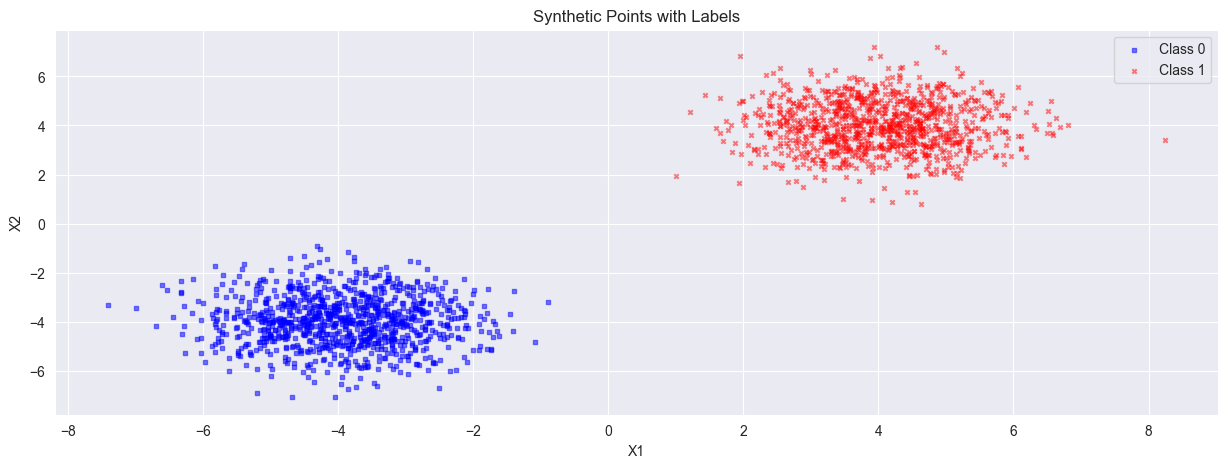

In [9]:
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()

# Visualize points and labels
visualize_points_and_labels(points, y_labels)

tensor(0.0486) tensor(1.)


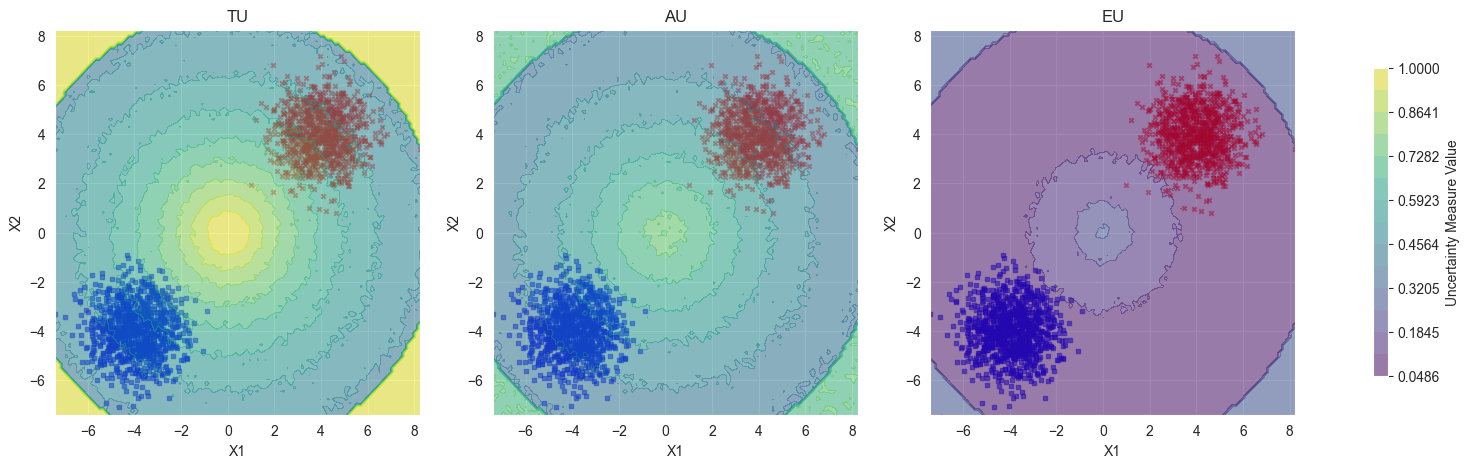

In [10]:
# Look at a given point and AU,EU,TU
def visualize_au_eu_tu_points(points):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the alphas of the points
    alpha_y = generate_2nd_order_beliefs(grid_points)
    # Get the AU, EU, and TU
    dist = Dirichlet(alpha_y)
    au, eu, tu = calculate_au_eu_tu_sampled(dist)

    # Shared value range
    all_vals = torch.concatenate([au, eu, tu])
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, data, title in zip(axes, [tu, au, eu], ["TU", "AU", "EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()

visualize_au_eu_tu_points(points)

## CF construction

### Validity
We now work in the scenario of creating a valid counter factual for our point x

In [11]:
point_of_interest = torch.tensor(np.array([-4,-4]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [12]:
def validity_procedure(point_to_explain, desired_validity=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    # Get the probs in the start
    _,probs = generate_target_and_probs(counter_factual)
    print(probs)
    target_probs = probs[0,desired_class]
    # Optimization Iteration
    while target_probs < desired_validity:
        optimizer.zero_grad()

        # Extract loss value
        _,probs = generate_target_and_probs(counter_factual)
        target_probs = probs[0,desired_class]
        # Calculate the loss
        loss = -target_probs

        # Backpropagate
        loss.backward()
        optimizer.step()

        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
    return counter_factual.detach(), counter_factual_steps

cf, cf_steps = validity_procedure(point_of_interest,desired_validity=0.9)

tensor([[0.8694, 0.1306]], grad_fn=<DivBackward0>)


In [13]:
cf

tensor([[5.6598, 5.6598]])

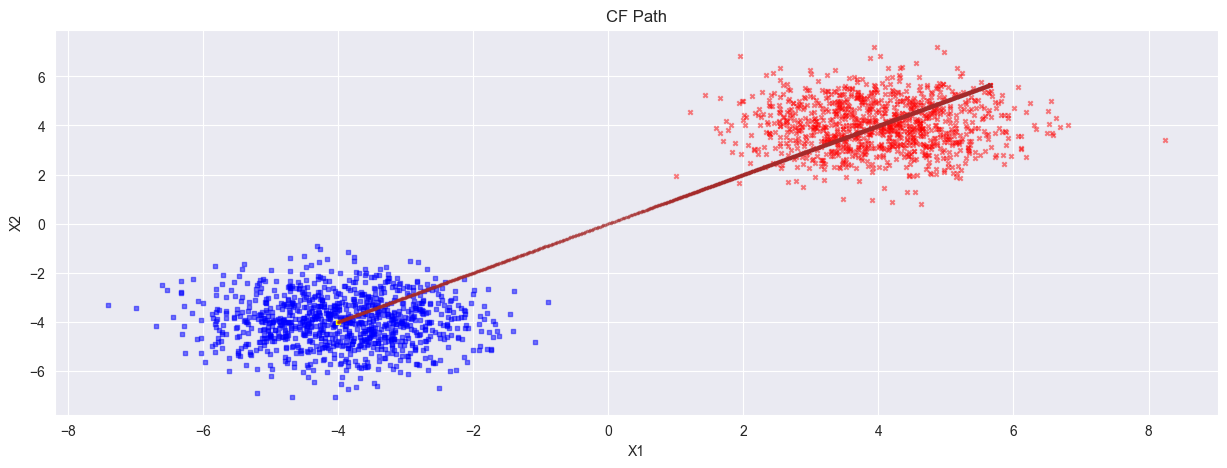

In [14]:
def visualize_cf_and_steps(cf,cf_steps, points, y_labels):
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # visualize the data itself
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

    ax.scatter(point_of_interest[:,0].detach(), point_of_interest[:,1].detach(), marker='s', s=10, alpha=1, color='yellow')

    ax.scatter(cf[:,0], cf[:,1], marker='x', s=10, alpha=1, color='red')

    ax.scatter(cf_steps[:,0], cf_steps[:,1], marker='.', s=10, alpha=0.5, color='brown')
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title("CF Path")
visualize_cf_and_steps(cf, cf_steps, points, y_labels)

# Plausability

In [15]:
point_of_interest = torch.tensor(np.array([-4,-4]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))
desired_class = 1

In [21]:
def plausability_procedure(point_to_explain, desired_plausability=0.8):
    counter_factual = point_to_explain.detach().clone().requires_grad_(True)
    counter_factual_steps = counter_factual.detach().clone()
    optimizer = torch.optim.Adam([counter_factual], lr=0.01)

    # Extract loss value
    alphas = generate_2nd_order_beliefs(counter_factual)
    probs = Dirichlet(alphas).mean
    _,eu,_ = calculate_au_eu_tu_sampled(Dirichlet(alphas))

    target_probs = probs[0,desired_class].add(eu)
    # Optimization Iteration
    while target_probs < desired_plausability:
        optimizer.zero_grad()

        # Extract loss value
        alphas = generate_2nd_order_beliefs(counter_factual)
        probs = Dirichlet(alphas).mean
        _,eu,_ = calculate_au_eu_tu_sampled(Dirichlet(alphas))

        target_probs = probs[0,desired_class]
        # Calculate the loss
        loss = (-target_probs).mul(eu)

        # Backpropagate
        loss.backward()
        optimizer.step()
        print(counter_factual, eu)
        # Save the intermediate steps
        counter_factual_steps = torch.cat((counter_factual_steps, counter_factual.detach()))
    return counter_factual.detach(), counter_factual_steps

cf, cf_steps = plausability_procedure(point_of_interest,desired_plausability=0.9)

tensor([[-3.9900, -3.9900]], requires_grad=True) tensor([0.0776])
tensor([[-3.9800, -3.9800]], requires_grad=True) tensor([0.0819])
tensor([[-3.9700, -3.9700]], requires_grad=True) tensor([0.0795])
tensor([[-3.9600, -3.9600]], requires_grad=True) tensor([0.0851])
tensor([[-3.9499, -3.9499]], requires_grad=True) tensor([0.0808])
tensor([[-3.9399, -3.9399]], requires_grad=True) tensor([0.0810])
tensor([[-3.9299, -3.9299]], requires_grad=True) tensor([0.0859])
tensor([[-3.9198, -3.9198]], requires_grad=True) tensor([0.0846])
tensor([[-3.9097, -3.9097]], requires_grad=True) tensor([0.0811])
tensor([[-3.8997, -3.8997]], requires_grad=True) tensor([0.0778])
tensor([[-3.8897, -3.8897]], requires_grad=True) tensor([0.0782])
tensor([[-3.8797, -3.8797]], requires_grad=True) tensor([0.0762])
tensor([[-3.8697, -3.8697]], requires_grad=True) tensor([0.0795])
tensor([[-3.8597, -3.8597]], requires_grad=True) tensor([0.0766])
tensor([[-3.8497, -3.8497]], requires_grad=True) tensor([0.0830])
tensor([[-

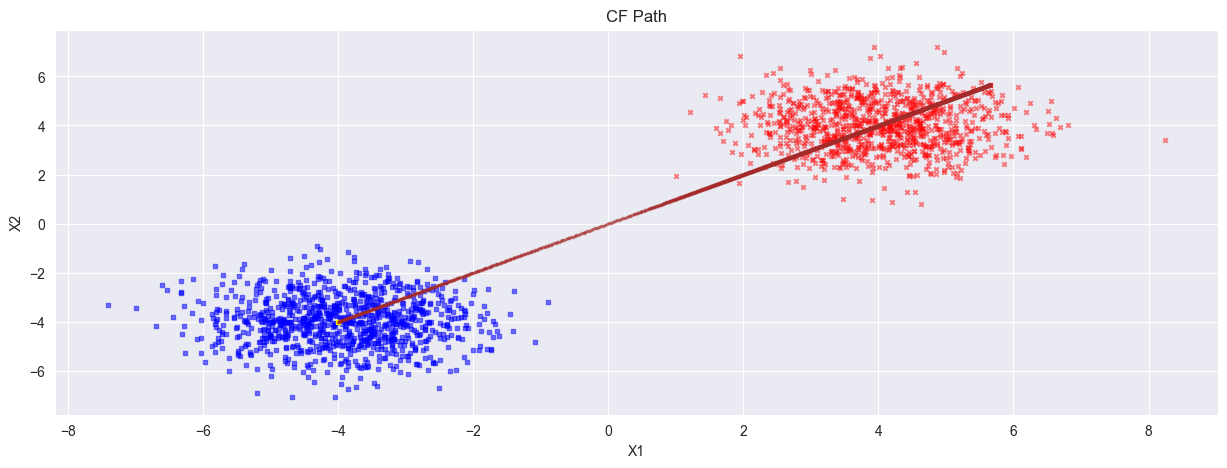

In [22]:
visualize_cf_and_steps(cf, cf_steps, points, y_labels)